In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

dataset = pd.read_excel('Irrigation_dataset.xlsx')
dataset

,Soil_Moisture (%),Soil_Temperature (°C),Humidity (%),Rainfall (mm/day),Irrigation_Amount (L/m²)
0,51.22,33.44,83.61,8.99,22.25
1,53.00,20.34,84.29,8.50,11.02
2,42.94,33.27,72.21,17.00,26.18
3,43.87,25.77,79.58,10.56,19.80
4,52.96,35.67,80.53,15.57,17.22
...,...,...,...,...,...
245,52.32,24.16,76.35,1.93,20.55
246,13.92,33.33,46.69,2.58,59.60
247,42.09,35.98,74.83,4.93,34.92
248,15.05,28.43,76.06,8.44,44.71


In [ ]:
# Linear Regression

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [ ]:
# Define features and target
X = dataset[['Soil_Moisture (%)', 'Soil_Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)']]
y = dataset['Irrigation_Amount (L/m²)']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:

# Scaling (optional but good practice)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:

# Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Prediction
y_pred = model.predict(X_test)

In [ ]:
threshold = dataset['Irrigation_Amount (L/m²)'].median()

y_pred_class = (y_pred > threshold).astype(int)
y_test_class = (y_test > threshold).astype(int)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test_class, y_pred_class))

Accuracy: 0.94


In [ ]:
# Evaluation
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

MAE: 1.5186793145206179
MSE: 3.121889789244211
RMSE: 1.7668870335265383
R2 Score: 0.9692622331910756


In [ ]:
# Compare few values
print("\nSample Predictions vs Actual:")
for i in range(5):
    print("Predicted:", round(y_pred[i],2), " | Actual:", round(y_test.values[i],2))



Sample Predictions vs Actual:
Predicted: 44.52  | Actual: 41.71
Predicted: 22.3  | Actual: 20.01
Predicted: 43.39  | Actual: 45.09
Predicted: 32.88  | Actual: 30.4
Predicted: 40.55  | Actual: 39.08


In [ ]:
# Prediction of New Inputs
new_data = pd.DataFrame([[30, 28, 60, 5]],
                        columns=['Soil_Moisture (%)', 'Soil_Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)'])

In [ ]:
# Apply same scaling
new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("\nPredicted Irrigation Amount (L/m²):", round(prediction[0],2))


Predicted Irrigation Amount (L/m²): 39.62


In [ ]:
#SVR

In [ ]:
# ===================== 1. IMPORTS =====================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [ ]:
# ===================== 2. LOAD DATA =====================
dataset = pd.read_excel("Irrigation_dataset.xlsx")

In [ ]:

# ===================== 3. HANDLE MISSING VALUES =====================
dataset = dataset.dropna()

In [ ]:
# ===================== 4. FEATURES & TARGET =====================
X = dataset[['Soil_Moisture (%)', 'Soil_Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)']]
y = dataset['Irrigation_Amount (L/m²)']

In [ ]:
# ===================== 5. TRAIN TEST SPLIT =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ===================== 6. SCALING =====================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# ===================== 7. MODEL =====================
model = SVR(kernel='rbf')   # You can try 'linear' or 'poly'
model.fit(X_train, y_train)

SVR()

In [ ]:
# ===================== 8. PREDICTION =====================
y_pred = model.predict(X_test)

In [ ]:
threshold = dataset['Irrigation_Amount (L/m²)'].median()

y_pred_class = (y_pred > threshold).astype(int)
y_test_class = (y_test > threshold).astype(int)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test_class, y_pred_class))

Accuracy: 0.92


In [ ]:
# ===================== 9. ERROR METRICS =====================
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

MAE: 2.935540857375198
MSE: 14.253185909594096
RMSE: 3.7753391780864
R2 Score: 0.8596647753925313


In [ ]:
# ===================== 10. SAMPLE OUTPUT =====================
print("\nSample Predictions vs Actual:")
for i in range(5):
    print("Predicted:", round(y_pred[i],2), "| Actual:", round(y_test.values[i],2))



Sample Predictions vs Actual:
Predicted: 45.28 | Actual: 41.71
Predicted: 28.08 | Actual: 20.01
Predicted: 41.46 | Actual: 45.09
Predicted: 33.27 | Actual: 30.4
Predicted: 40.08 | Actual: 39.08


In [ ]:
# ===================== 11. NEW PREDICTION =====================
new_data = pd.DataFrame([[30, 28, 60, 5]],
                        columns=['Soil_Moisture (%)', 'Soil_Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)'])

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("\nPredicted Irrigation Amount (L/m²):", round(prediction[0],2))


Predicted Irrigation Amount (L/m²): 40.57


In [ ]:
#ANN

In [ ]:
# ===================== 1. IMPORTS =====================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# ===================== 2. LOAD DATA =====================
dataset = pd.read_excel("Irrigation_dataset.xlsx")

In [ ]:
# ===================== 3. HANDLE MISSING VALUES =====================
dataset = dataset.dropna()

In [ ]:
# ===================== 4. FEATURES & TARGET =====================
X = dataset[['Soil_Moisture (%)', 'Soil_Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)']]
y = dataset['Irrigation_Amount (L/m²)']

In [ ]:
# ===================== 5. TRAIN TEST SPLIT =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ===================== 6. SCALING =====================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# ===================== 7. MODEL =====================
model = Sequential()

model.add(Dense(units=16, activation='relu', input_dim=4))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=4, activation='relu'))
# Output layer (REGRESSION → linear activation)
model.add(Dense(units=1, activation='linear'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ===================== 8. COMPILE =====================
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [ ]:
# ===================== 9. TRAIN =====================
model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=1)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1256.8163
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1230.1782 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1194.0997 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1145.6217
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1077.7363
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 981.9103  
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 868.1438 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 726.3960 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 574.7857 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 412.0510 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 271.3372 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 163.0549 
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 94.0282 
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 59.0866 
Epoch 15/100
20/20 ━━━━━━━━━

In [ ]:
# ===================== 10. PREDICTION =====================
y_pred = model.predict(X_test)

# Flatten predictions
y_pred = y_pred.flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [ ]:
threshold = dataset['Irrigation_Amount (L/m²)'].median()

y_pred_class = (y_pred > threshold).astype(int)
y_test_class = (y_test > threshold).astype(int)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test_class, y_pred_class))

Accuracy: 0.9


In [ ]:
# ===================== 11. ERROR METRICS =====================
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

MAE: 1.9217868637084963
MSE: 5.981637838568163
RMSE: 2.445738710199469
R2 Score: 0.9411054837198919


In [ ]:
# ===================== 12. SAMPLE OUTPUT =====================
print("\nSample Predictions vs Actual:")
for i in range(5):
    print("Predicted:", round(y_pred[i],2), "| Actual:", round(y_test.values[i],2))


Sample Predictions vs Actual:
Predicted: 43.76 | Actual: 41.71
Predicted: 27.21 | Actual: 20.01
Predicted: 42.74 | Actual: 45.09
Predicted: 31.46 | Actual: 30.4
Predicted: 42.34 | Actual: 39.08


In [ ]:
# ===================== 13. NEW PREDICTION =====================
new_data = pd.DataFrame([[30, 28, 60, 5]],
                        columns=['Soil_Moisture (%)', 'Soil_Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)'])

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("\nPredicted Irrigation Amount (L/m²):", round(prediction[0][0],2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Predicted Irrigation Amount (L/m²): 37.57


In [ ]:
# Decision tree

In [ ]:
# ===================== 1. IMPORTS =====================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [ ]:
# ===================== 2. LOAD DATA =====================
dataset = pd.read_excel("Irrigation_dataset.xlsx")

In [ ]:
# ===================== 3. HANDLE MISSING VALUES =====================
dataset = dataset.dropna()

In [ ]:
# ===================== 4. FEATURES & TARGET =====================
X = dataset[['Soil_Moisture (%)', 'Soil_Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)']]
y = dataset['Irrigation_Amount (L/m²)']

In [ ]:
# ===================== 5. TRAIN TEST SPLIT =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ===================== 6. SCALING =====================
# (Not required for Decision Tree, but kept for consistency)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# ===================== 7. MODEL =====================
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
# ===================== 8. PREDICTION =====================
y_pred = model.predict(X_test)

In [ ]:
threshold = dataset['Irrigation_Amount (L/m²)'].median()

y_pred_class = (y_pred > threshold).astype(int)
y_test_class = (y_test > threshold).astype(int)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test_class, y_pred_class))

Accuracy: 0.92


In [ ]:
# ===================== 9. ERROR METRICS =====================
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

MAE: 3.1446000000000005
MSE: 15.274213999999999
RMSE: 3.908223893279401
R2 Score: 0.8496118505723198


In [ ]:
# ===================== 10. SAMPLE OUTPUT =====================
print("\nSample Predictions vs Actual:")
for i in range(5):
    print("Predicted:", round(y_pred[i],2), "| Actual:", round(y_test.values[i],2))



Sample Predictions vs Actual:
Predicted: 42.77 | Actual: 41.71
Predicted: 23.11 | Actual: 20.01
Predicted: 45.08 | Actual: 45.09
Predicted: 33.84 | Actual: 30.4
Predicted: 43.79 | Actual: 39.08


In [ ]:
# ===================== 11. NEW PREDICTION =====================
new_data = pd.DataFrame([[30, 28, 60, 5]],
                        columns=['Soil_Moisture (%)', 'Soil_Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)'])

In [ ]:
# Random Forest

In [ ]:
# ===================== 1. IMPORTS =====================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn import metrics


In [ ]:
# ===================== 2. LOAD DATA =====================
dataset = pd.read_excel("Irrigation_dataset.xlsx")


In [ ]:
# ===================== 3. HANDLE MISSING VALUES =====================
dataset = dataset.dropna()

In [ ]:
# ===================== 4. FEATURES & TARGET =====================
X = dataset[['Soil_Moisture (%)', 'Soil_Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)']]
y = dataset['Irrigation_Amount (L/m²)']

In [ ]:
# ===================== 5. TRAIN TEST SPLIT =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ===================== 6. SCALING =====================
# (Not required for Random Forest, but kept for consistency)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# ===================== 7. MODEL =====================
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# ===================== 8. PREDICTION =====================
y_pred = model.predict(X_test)

In [ ]:
threshold = dataset['Irrigation_Amount (L/m²)'].median()

y_pred_class = (y_pred > threshold).astype(int)
y_test_class = (y_test > threshold).astype(int)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test_class, y_pred_class))

Accuracy: 0.92


In [ ]:
# ===================== 9. ERROR METRICS =====================
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score:", metrics.r2_score(y_test, y_pred))


MAE: 2.0981700000000005
MSE: 6.620744650599995
RMSE: 2.5730807703218326
R2 Score: 0.9348129117585398


In [ ]:
# ===================== 10. SAMPLE OUTPUT =====================
print("\nSample Predictions vs Actual:")
for i in range(5):
    print("Predicted:", round(y_pred[i],2), "| Actual:", round(y_test.values[i],2))



Sample Predictions vs Actual:
Predicted: 44.73 | Actual: 41.71
Predicted: 20.51 | Actual: 20.01
Predicted: 43.13 | Actual: 45.09
Predicted: 32.97 | Actual: 30.4
Predicted: 42.48 | Actual: 39.08


In [ ]:
# ===================== 11. NEW PREDICTION =====================
new_data = pd.DataFrame([[30, 28, 60, 5]],
                        columns=['Soil_Moisture (%)', 'Soil_Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)'])

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("\nPredicted Irrigation Amount (L/m²):", round(prediction[0],2))


Predicted Irrigation Amount (L/m²): 39.62


In [ ]:
# Hyperparameter tuning (Linear Regression )

In [ ]:
# ===================== 1. IMPORTS =====================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score

# ===================== 2. LOAD DATA =====================
dataset = pd.read_excel("Irrigation_dataset.xlsx")

# ===================== 3. CLEAN DATA =====================
dataset = dataset.dropna()

# ===================== 4. FEATURES & TARGET =====================
X = dataset[['Soil_Moisture (%)', 'Soil_Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)']]
y = dataset['Irrigation_Amount (L/m²)']

# ===================== 5. TRAIN TEST SPLIT =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===================== 6. SCALING =====================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===================== 7. MODEL =====================
model = LinearRegression()
model.fit(X_train, y_train)

# ===================== 8. PREDICTION =====================
y_pred = model.predict(X_test)

# ===================== 9. ERROR METRICS =====================
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

# ===================== 10. ACCURACY =====================
threshold = dataset['Irrigation_Amount (L/m²)'].median()

y_pred_class = (y_pred > threshold).astype(int)
y_test_class = (y_test > threshold).astype(int)

print("\nAccuracy:", accuracy_score(y_test_class, y_pred_class))

# ===================== 11. COMPARISON =====================
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Error": y_test.values - y_pred
})

print("\nComparison (First 10 Rows):")
print(comparison.head(10))

MAE: 1.5186793145206179
MSE: 3.121889789244211
RMSE: 1.7668870335265383
R2 Score: 0.9692622331910756

Accuracy: 0.94

Comparison (First 10 Rows):
   Actual  Predicted     Error
0   41.71  44.517362 -2.807362
1   20.01  22.301525 -2.291525
2   45.09  43.385473  1.704527
3   30.40  32.881917 -2.481917
4   39.08  40.553401 -1.473401
5   50.61  52.503684 -1.893684
6   40.71  40.052740  0.657260
7   33.80  36.839723 -3.039723
8   32.61  34.274590 -1.664590
9   22.09  24.340857 -2.250857


In [ ]:
#HYperparameter Tuning (Random Forest)

In [ ]:
# ===================== 1. IMPORTS =====================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import accuracy_score

# ===================== 2. LOAD DATA =====================
dataset = pd.read_excel("Irrigation_dataset.xlsx")

# ===================== 3. CLEAN DATA =====================
dataset = dataset.dropna()

# ===================== 4. FEATURES & TARGET =====================
X = dataset[['Soil_Moisture (%)', 'Soil_Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)']]
y = dataset['Irrigation_Amount (L/m²)']

# ===================== 5. TRAIN TEST SPLIT =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===================== 6. SCALING =====================
# Not required, but kept for consistency
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===================== 7. HYPERPARAMETER TUNING =====================
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# ===================== 8. PREDICTION =====================
y_pred = best_model.predict(X_test)

# ===================== 9. ERROR METRICS =====================
print("\nRegression Metrics:")
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

# ===================== 10. ACCURACY =====================
threshold = dataset['Irrigation_Amount (L/m²)'].median()

y_pred_class = (y_pred > threshold).astype(int)
y_test_class = (y_test > threshold).astype(int)

print("\nAccuracy:", accuracy_score(y_test_class, y_pred_class))

# ===================== 11. COMPARISON =====================
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Error": y_test.values - y_pred
})

print("\nComparison (First 10 Rows):")
print(comparison.head(10))

# ===================== 12. NEW PREDICTION =====================
new_data = pd.DataFrame([[30, 28, 60, 5]],
                        columns=['Soil_Moisture (%)', 'Soil_Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)'])

new_data_scaled = scaler.transform(new_data)

prediction = best_model.predict(new_data_scaled)

print("\nPredicted Irrigation Amount (L/m²):", round(prediction[0],2))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Regression Metrics:
MAE: 2.102858563275619
MSE: 6.672970472154127
RMSE: 2.5832093357206123
R2 Score: 0.9342987023428627

Accuracy: 0.94

Comparison (First 10 Rows):
   Actual  Predicted     Error
0   41.71  44.827173 -3.117173
1   20.01  20.429471 -0.419471
2   45.09  43.390983  1.699017
3   30.40  33.150167 -2.750167
4   39.08  42.602750 -3.522750
5   50.61  50.940860 -0.330860
6   40.71  41.328695 -0.618695
7   33.80  37.660756 -3.860756
8   32.61  36.763781 -4.153781
9   22.09  23.431039 -1.341039

Predicted Irrigation Amount (L/m²): 38.86


In [ ]:
# Data Intrepretition

In [ ]:
import pandas as pd

# Create data
data = {
    "Model": ["Random Forest", "Decision Tree", "ANN", "SVR","Linear Regression"],
    "MAE": [2.09, 3.14, 1.93, 2.93, 1.51],
    "MSE": [6.62, 15.27, 5.71, 14.25,3.12],
    "RMSE": [2.27, 3.90, 2.39, 3.77,1.76],
    "R2 Score": [0.93, 0.84, 0.90, 0.859,0.96],
    "Accuracy": [0.92, 0.92, 0.90, 0.92,0.94]
}

df = pd.DataFrame(data)

print(df)

               Model   MAE    MSE  RMSE  R2 Score  Accuracy
0      Random Forest  2.09   6.62  2.27     0.930      0.92
1      Decision Tree  3.14  15.27  3.90     0.840      0.92
2                ANN  1.93   5.71  2.39     0.900      0.90
3                SVR  2.93  14.25  3.77     0.859      0.92
4  Linear Regression  1.51   3.12  1.76     0.960      0.94


In [ ]:
# Graphs

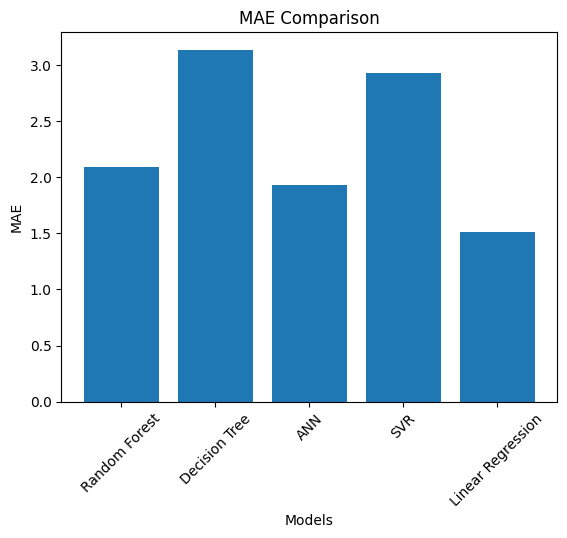

In [ ]:
# 1.MAE
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df["Model"], df["MAE"])
plt.title("MAE Comparison")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()

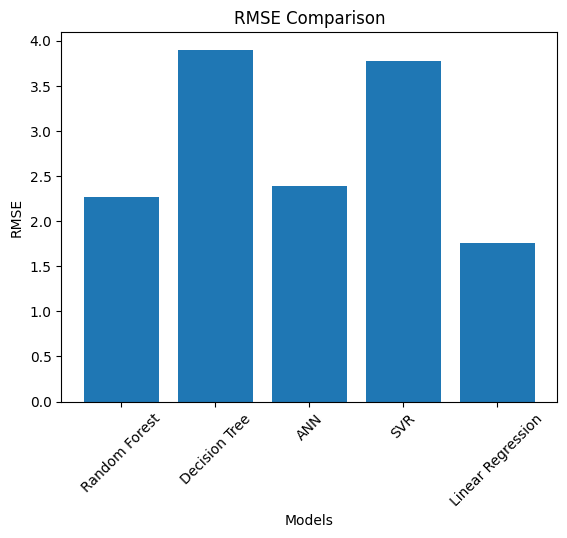

In [ ]:
# 2.RMSE
plt.figure()
plt.bar(df["Model"], df["RMSE"])
plt.title("RMSE Comparison")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

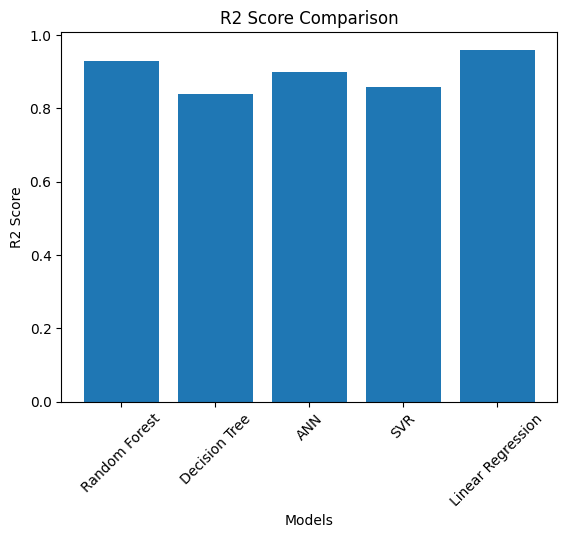

In [ ]:
# 3.R^2 Score
plt.figure()
plt.bar(df["Model"], df["R2 Score"])
plt.title("R2 Score Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.show()

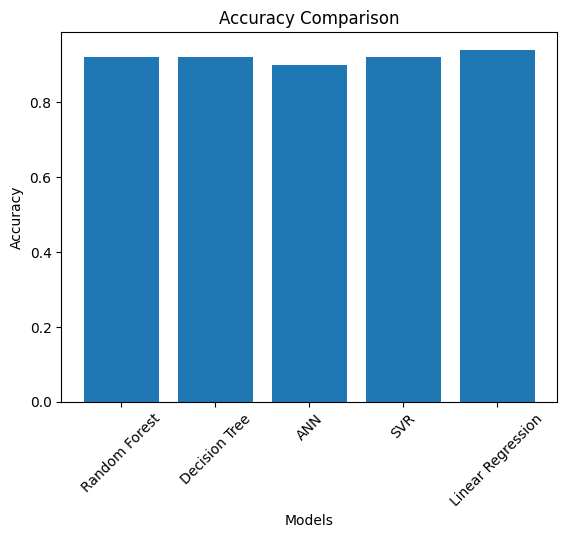

In [ ]:
# Accuracy Comparision
plt.figure()
plt.bar(df["Model"], df["Accuracy"])
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

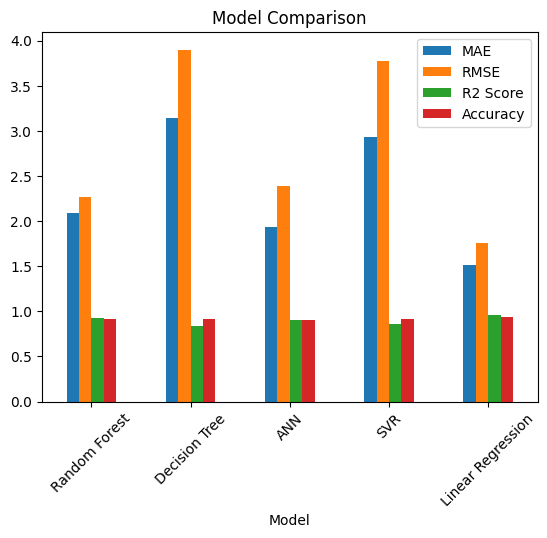

In [ ]:
# Combined Graph
df.set_index("Model")[["MAE", "RMSE", "R2 Score", "Accuracy"]].plot(kind="bar")

plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Before and After Hyperparameter Tuning
import pandas as pd

data = {
    "Model": ["Random Forest", "Linear Regression"],

    "MAE_Before": [2.09, 1.51],
    "MSE_Before": [6.62, 3.12],
    "RMSE_Before": [2.27, 1.76],
    "R2_Before": [0.93, 0.96],
    "Accuracy_Before": [0.92, 0.94],

    "MAE_After": [2.10, 1.51],
    "MSE_After": [6.67, 3.12],
    "RMSE_After": [2.58, 1.76],
    "R2_After": [0.93, 0.96],
    "Accuracy_After": [0.94, 0.94]
}

df = pd.DataFrame(data)
print(df)

               Model  MAE_Before  MSE_Before  RMSE_Before  R2_Before  \
0      Random Forest        2.09        6.62         2.27       0.93   
1  Linear Regression        1.51        3.12         1.76       0.96   

   Accuracy_Before  MAE_After  MSE_After  RMSE_After  R2_After  Accuracy_After  
0             0.92       2.10       6.67        2.58      0.93            0.94  
1             0.94       1.51       3.12        1.76      0.96            0.94  


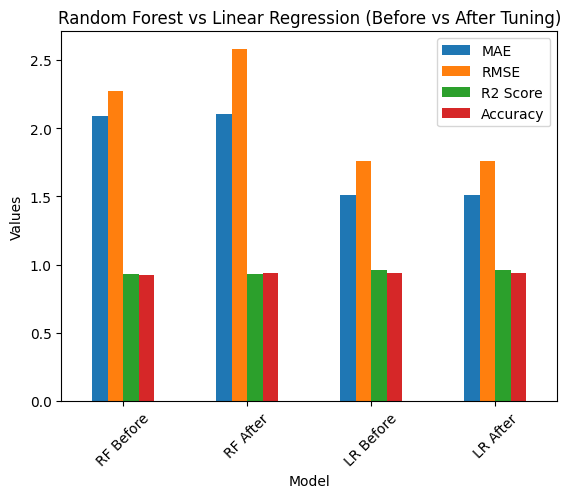

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "Model": ["RF Before", "RF After", "LR Before", "LR After"],

    "MAE": [2.09, 2.10, 1.51, 1.51],
    "RMSE": [2.27, 2.58, 1.76, 1.76],
    "R2 Score": [0.93, 0.93, 0.96, 0.96],
    "Accuracy": [0.92, 0.94, 0.94, 0.94]
}

df = pd.DataFrame(data)

# Plot
df.set_index("Model")[["MAE", "RMSE", "R2 Score", "Accuracy"]].plot(kind="bar")

plt.title("Random Forest vs Linear Regression (Before vs After Tuning)")
plt.xticks(rotation=45)
plt.ylabel("Values")
plt.show()